<a href="https://colab.research.google.com/github/ManoloVM21/MachineLearningTeam4/blob/main/ManoloVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import *
!pip install lets-plot
import lets_plot

campaign = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')
campaign.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.8 MB/s eta 0:00:00


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
campaign.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000,37069.000000
mean,40.025493,2.564407,962.221803,0.173730,0.081526,93.576551,-40.494829,3.621945,5167.010650
std,10.435288,2.764084,187.531477,0.496159,1.572287,0.579339,4.628895,1.734496,72.294476
min,17.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37069 entries, 0 to 37068
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             37069 non-null  int64  
 1   job             37069 non-null  object 
 2   marital         37069 non-null  object 
 3   education       37069 non-null  object 
 4   default         37069 non-null  object 
 5   housing         37069 non-null  object 
 6   loan            37069 non-null  object 
 7   contact         37069 non-null  object 
 8   month           37069 non-null  object 
 9   day_of_week     37069 non-null  object 
 10  campaign        37069 non-null  int64  
 11  pdays           37069 non-null  int64  
 12  previous        37069 non-null  int64  
 13  poutcome        37069 non-null  object 
 14  emp.var.rate    37069 non-null  float64
 15  cons.price.idx  37069 non-null  float64
 16  cons.conf.idx   37069 non-null  float64
 17  euribor3m       37069 non-null 

In [7]:
import lets_plot

# Box plot for 'age' vs 'y'
plot_age_y = (lets_plot.ggplot(campaign, lets_plot.aes(x='y', y='age', fill='y')) +
              lets_plot.geom_boxplot() +
              lets_plot.ggtitle('Distribution of Age per Subscription Status') +
              lets_plot.xlab('Subscription Status (y)') +
              lets_plot.ylab('Age'))

plot_age_y.show()
print("Generated box plot for 'age' vs. 'y' (subscription status).")

Generated box plot for 'age' vs. 'y' (subscription status).


In [6]:
import lets_plot

# Calculate the mean emp.var.rate for each 'y' category
mean_emp_var_rate_by_y = campaign.groupby('y')['emp.var.rate'].mean().reset_index()

# Create a bar plot for mean emp.var.rate per 'y'
plot_mean_emp_var_rate_by_y = (lets_plot.ggplot(mean_emp_var_rate_by_y, lets_plot.aes(x='y', y='emp.var.rate', fill='y')) +
                                 lets_plot.geom_bar(stat='identity') +
                                 lets_plot.ggtitle('Mean Employment Variation Rate by Subscription Status') +
                                 lets_plot.xlab('Subscription Status (y)') +
                                 lets_plot.ylab('Mean Employment Variation Rate'))

plot_mean_emp_var_rate_by_y.show()
print("Generated bar plot for mean 'emp.var.rate' by 'y' (subscription status).")

Generated bar plot for mean 'emp.var.rate' by 'y' (subscription status).


When the economy and employment is uncertain, people are more propense to subscribe. Which has sense because they are looking for something safe to invest on.
**The model should highly consider the current economy**

In [8]:
# Box plot for 'cons.conf.idx' vs 'y'
plot_cons_conf_idx_y = (lets_plot.ggplot(campaign, lets_plot.aes(x='y', y='cons.conf.idx', fill='y')) +
                        lets_plot.geom_boxplot() +
                        lets_plot.ggtitle('Distribución de Índice de Confianza del Consumidor por Suscripción') +
                        lets_plot.xlab('Suscripción al Depósito a Plazo (y)') +
                        lets_plot.ylab('Índice de Confianza del Consumidor (cons.conf.idx)'))
plot_cons_conf_idx_y.show()

This is more related to the previous one



In [9]:
# Box plot for 'euribor3m' vs 'y'
plot_euribor3m_y = (lets_plot.ggplot(campaign, lets_plot.aes(x='y', y='euribor3m', fill='y')) +
                    lets_plot.geom_boxplot() +
                    lets_plot.ggtitle('Distribución de Tasa Euribor a 3 Meses por Suscripción') +
                    lets_plot.xlab('Suscripción al Depósito a Plazo (y)') +
                    lets_plot.ylab('Tasa Euribor a 3 Meses (euribor3m)'))
plot_euribor3m_y.show()

low interest rate

In [10]:
# Box plot for 'nr.employed' vs 'y'
plot_nr_employed_y = (lets_plot.ggplot(campaign, lets_plot.aes(x='y', y='nr.employed', fill='y')) +
                      lets_plot.geom_boxplot() +
                      lets_plot.ggtitle('Distribución de Número de Empleados por Suscripción') +
                      lets_plot.xlab('Suscripción al Depósito a Plazo (y)') +
                      lets_plot.ylab('Número de Empleados (nr.employed)'))
plot_nr_employed_y.show()

strong relationship with employment variation. One should be deleted.

# Task
Identify and analyze the relationship between each categorical variable (job, marital, education, default, housing, loan, contact, month, day_of_week, and poutcome) and the 'y' (subscription to a term deposit) target variable by calculating the probability of 'y' being 'yes' for each category and visualizing these relationships using bar charts, and then summarize the observed patterns.

## Identify Categorical Variables

### Subtask:
Identify all categorical columns in the 'campaign' DataFrame, excluding the target variable 'y'.


**Reasoning**:
To identify categorical variables, I will select columns with the 'object' data type from the `campaign` DataFrame and then remove the target variable 'y' from this list.



In [11]:
categorical_cols = campaign.select_dtypes(include='object').columns.tolist()
if 'y' in categorical_cols:
    categorical_cols.remove('y')

print(f"Categorical variables (excluding 'y'): {categorical_cols}")

Categorical variables (excluding 'y'): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


**Reasoning**:
The previous code failed because the 'campaign' DataFrame was not defined in the execution environment. I need to re-initialize the 'campaign' DataFrame by loading the CSV file again before identifying the categorical columns.



In [12]:
import pandas as pd
campaign = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')
categorical_cols = campaign.select_dtypes(include='object').columns.tolist()
if 'y' in categorical_cols:
    categorical_cols.remove('y')

print(f"Categorical variables (excluding 'y'): {categorical_cols}")

Categorical variables (excluding 'y'): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


**Reasoning**:
Now that the categorical variables have been identified, the next step is to calculate the probability of 'y' being 'yes' for each category within the first categorical variable, 'job', and visualize this relationship using a bar chart. This will involve grouping the data by 'job', calculating the mean of 'y' (after converting 'yes' to 1 and 'no' to 0), and then plotting the results.



In [13]:
import lets_plot
import pandas as pd

# Convert 'y' to numerical (1 for 'yes', 0 for 'no') for probability calculation
campaign['y_numeric'] = campaign['y'].apply(lambda x: 1 if x == 'yes' else 0)

# --- Plot 1: Histogram of Age Distribution ---
plot_age_histogram = (lets_plot.ggplot(campaign, lets_plot.aes(x='age')) +
                      lets_plot.geom_histogram(binwidth=5, fill='skyblue', color='black') +
                      lets_plot.ggtitle('Distribution of Age') +
                      lets_plot.xlab('Age') +
                      lets_plot.ylab('Count'))

plot_age_histogram.show()
print("Generated histogram for age distribution.")

# --- Plot 2: Probability of 'yes' by Age Group ---
# Create age bins
age_bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels = ['0-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99']
campaign['age_group'] = pd.cut(campaign['age'], bins=age_bins, labels=age_labels, right=False)

# Calculate the probability of 'y' being 'yes' for each age group
age_group_probability = campaign.groupby('age_group', observed=False)['y_numeric'].mean().reset_index()
age_group_probability.columns = ['age_group', 'probability_yes']

plot_age_probability = (lets_plot.ggplot(age_group_probability, lets_plot.aes(x='age_group', y='probability_yes', fill='age_group')) +
                          lets_plot.geom_bar(stat='identity') +
                          lets_plot.ggtitle('Probability of Subscription by Age Group') +
                          lets_plot.xlab('Age Group') +
                          lets_plot.ylab('Probability of Subscription (y=yes)') +
                          lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1)))

plot_age_probability.show()
print("Generated bar chart for probability of subscription by age group.")

Generated histogram for age distribution.


Generated bar chart for probability of subscription by age group.


In [14]:
import lets_plot

# Calculate the counts of 'yes' and 'no' for each job category
job_counts = campaign.groupby(['job', 'y']).size().reset_index(name='count')

# Create the stacked bar chart for 'job' counts
plot_job_counts = (lets_plot.ggplot(job_counts, lets_plot.aes(x='job', y='count', fill='y')) +
                   lets_plot.geom_bar(stat='identity', position='stack') +
                   lets_plot.ggtitle('Subscription Counts by Job Category') +
                   lets_plot.xlab('Job Category') +
                   lets_plot.ylab('Count') +
                   lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1))) # Rotate x-axis labels for readability

plot_job_counts.show()
print("Generated stacked bar chart for 'job' category vs. subscription counts.")

Generated stacked bar chart for 'job' category vs. subscription counts.


In [15]:
import lets_plot

# Filter for only 'yes' subscriptions
yes_subscribers_per_job = campaign[campaign['y'] == 'yes'].groupby('job').size().reset_index(name='count_yes')

# Sort the DataFrame by 'count_yes' in descending order
yes_subscribers_per_job = yes_subscribers_per_job.sort_values(by='count_yes', ascending=False)

# Create the bar chart for 'yes' subscribers per job
plot_yes_subscribers_per_job = (lets_plot.ggplot(yes_subscribers_per_job, lets_plot.aes(x='job', y='count_yes', fill='job')) +
                                lets_plot.geom_bar(stat='identity') +
                                lets_plot.ggtitle('Number of \'Yes\' Subscribers per Job Category') +
                                lets_plot.xlab('Job Category') +
                                lets_plot.ylab('Count of \'Yes\' Subscribers') +
                                lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1))) # Rotate x-axis labels for readability

plot_yes_subscribers_per_job.show()
print("Generated bar chart for 'yes' subscribers per job category, sorted descending.")

Generated bar chart for 'yes' subscribers per job category, sorted descending.


In [16]:
import lets_plot

# Convert 'y' to numerical (1 for 'yes', 0 for 'no') for probability calculation
campaign['y_numeric'] = campaign['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Calculate the probability of 'y' being 'yes' for each job category
job_probability = campaign.groupby('job')['y_numeric'].mean().reset_index()
job_probability.columns = ['job', 'probability_yes']

# Create the bar chart for 'job'
plot_job_probability = (lets_plot.ggplot(job_probability, lets_plot.aes(x='job', y='probability_yes', fill='job')) +
                        lets_plot.geom_bar(stat='identity') +
                        lets_plot.ggtitle('Probability of Subscription by Job Category') +
                        lets_plot.xlab('Job Category') +
                        lets_plot.ylab('Probability of Subscription (y=yes)') +
                        lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1)))

plot_job_probability.show()
print("Generated bar chart for 'job' category vs. subscription probability.")

Generated bar chart for 'job' category vs. subscription probability.


**Reasoning**:
Continuing with the subtask, the next categorical variable to analyze is 'marital'. I will calculate the probability of 'y' being 'yes' for each marital status category and then visualize this relationship using a bar chart, similar to how the 'job' variable was handled.



In [17]:
marital_probability = campaign.groupby('marital')['y_numeric'].mean().reset_index()
marital_probability.columns = ['marital', 'probability_yes']

plot_marital_probability = (lets_plot.ggplot(marital_probability, lets_plot.aes(x='marital', y='probability_yes', fill='marital')) +
                            lets_plot.geom_bar(stat='identity') +
                            lets_plot.ggtitle('Probability of Subscription by Marital Status') +
                            lets_plot.xlab('Marital Status') +
                            lets_plot.ylab('Probability of Subscription (y=yes)'))

plot_marital_probability.show()
print("Generated bar chart for 'marital' category vs. subscription probability.")

Generated bar chart for 'marital' category vs. subscription probability.


**Reasoning**:
Following the previous steps, I will now analyze the 'education' categorical variable. I will calculate the probability of 'y' being 'yes' for each education level and then visualize this relationship using a bar chart, similar to the 'job' and 'marital' variables.



In [18]:
education_probability = campaign.groupby('education')['y_numeric'].mean().reset_index()
education_probability.columns = ['education', 'probability_yes']

plot_education_probability = (lets_plot.ggplot(education_probability, lets_plot.aes(x='education', y='probability_yes', fill='education')) +
                              lets_plot.geom_bar(stat='identity') +
                              lets_plot.ggtitle('Probability of Subscription by Education Level') +
                              lets_plot.xlab('Education Level') +
                              lets_plot.ylab('Probability of Subscription (y=yes)') +
                              lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1)))

plot_education_probability.show()
print("Generated bar chart for 'education' category vs. subscription probability.")

Generated bar chart for 'education' category vs. subscription probability.


**Reasoning**:
Continuing the analysis of categorical variables, I will now process the 'default' variable. I will calculate the probability of 'y' being 'yes' for each 'default' status and visualize this relationship using a bar chart.



In [19]:
default_probability = campaign.groupby('default')['y_numeric'].mean().reset_index()
default_probability.columns = ['default', 'probability_yes']

plot_default_probability = (lets_plot.ggplot(default_probability, lets_plot.aes(x='default', y='probability_yes', fill='default')) +
                            lets_plot.geom_bar(stat='identity') +
                            lets_plot.ggtitle('Probability of Subscription by Default Status') +
                            lets_plot.xlab('Default Status') +
                            lets_plot.ylab('Probability of Subscription (y=yes)'))

plot_default_probability.show()
print("Generated bar chart for 'default' category vs. subscription probability.")

Generated bar chart for 'default' category vs. subscription probability.


**Reasoning**:
Continuing the analysis of categorical variables, I will now process the 'month' variable. I will calculate the probability of 'y' being 'yes' for each month and visualize this relationship using a bar chart, similar to the previous categorical variables.



In [20]:
#I LIKE THIS ONE
month_probability = campaign.groupby('month')['y_numeric'].mean().reset_index()
month_probability.columns = ['month', 'probability_yes']

plot_month_probability = (lets_plot.ggplot(month_probability, lets_plot.aes(x='month', y='probability_yes', fill='month')) +
                            lets_plot.geom_bar(stat='identity') +
                            lets_plot.ggtitle('Probability of Subscription by Contact Month') +
                            lets_plot.xlab('Contact Month') +
                            lets_plot.ylab('Probability of Subscription (y=yes)'))

plot_month_probability.show()
print("Generated bar chart for 'month' category vs. subscription probability.")

Generated bar chart for 'month' category vs. subscription probability.


In [21]:
import lets_plot
import pandas as pd

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_counts = campaign.groupby(['month', 'y']).size().reset_index(name='count')

month_counts['month'] = pd.Categorical(month_counts['month'], categories=month_order, ordered=True)

month_counts = month_counts.sort_values('month')

plot_month_counts = (lets_plot.ggplot(month_counts, lets_plot.aes(x='month', y='count', fill='y')) +
                     lets_plot.geom_bar(stat='identity', position='stack') +
                     lets_plot.ggtitle('Subscription Counts by Contact Month (Chronological)') +
                     lets_plot.xlab('Contact Month') +
                     lets_plot.ylab('Count') +
                     lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1)))

plot_month_counts.show()
print("Generated stacked bar chart for 'month' category vs. subscription counts, ordered chronologically.")

Generated stacked bar chart for 'month' category vs. subscription counts, ordered chronologically.


/tmp/ipython-input-3314839999.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_counts = campaign.groupby(['month', 'y']).size().reset_index(name='count')
/tmp/ipython-input-3314839999.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_emp_var_rate_monthly = campaign.groupby('month')['emp.var.rate'].mean().reset_index()
/tmp/ipython-input-3314839999.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mon

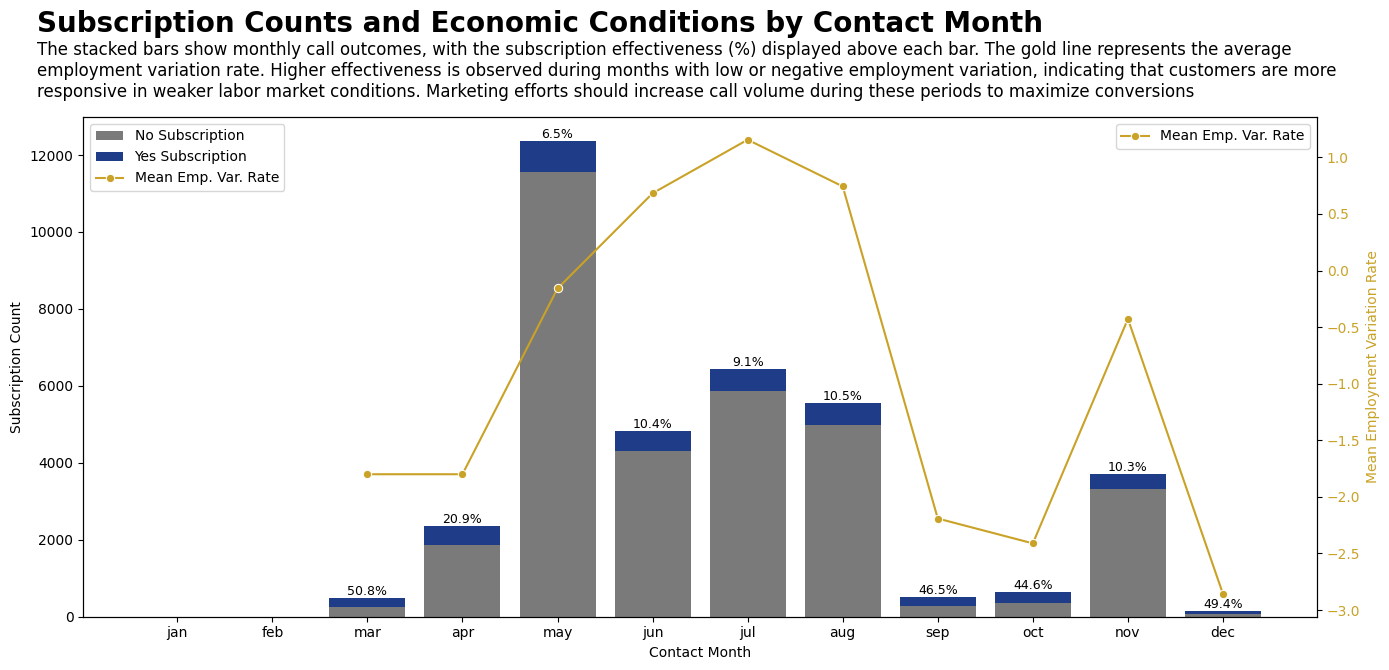

Generated dual-axis plot for Subscription Counts and Mean Employment Variation Rate by Contact Month using Matplotlib/Seaborn with updated lighter color palette.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'y_numeric' column exists for calculations
if 'y_numeric' not in campaign.columns:
    campaign['y_numeric'] = campaign['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Define month order for chronological display
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Convert 'month' column to categorical type with the specified order
campaign['month'] = pd.Categorical(campaign['month'], categories=month_order, ordered=True)

# Calculate subscription counts by month and 'y'
month_counts = campaign.groupby(['month', 'y']).size().reset_index(name='count')

# Calculate mean emp.var.rate by month
mean_emp_var_rate_monthly = campaign.groupby('month')['emp.var.rate'].mean().reset_index()

# Calculate the probability of 'y' being 'yes' for each month


month_probability = campaign.groupby('month')['y_numeric'].mean().reset_index()
month_probability.columns = ['month', 'probability_yes']

# Pivot month_counts for stacked bar chart
# Reindex to ensure all months are present and in order, filling missing with 0
month_pivot = month_counts.pivot_table(index='month', columns='y', values='count', fill_value=0).reindex(month_order, fill_value=0)

# Create the figure and primary axes (for Subscription Counts)
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot stacked bar chart on ax1 with specified colors
bar_no = ax1.bar(month_pivot.index, month_pivot['no'], color='#7A7A7A', label='No Subscription')
bar_yes = ax1.bar(month_pivot.index, month_pivot['yes'], bottom=month_pivot['no'], color='#1F3C88', label='Yes Subscription')

ax1.set_xlabel('Contact Month')
ax1.set_ylabel('Subscription Count', color='black')
ax1.tick_params(axis='y', labelcolor='black')
# ax1.grid(True, linestyle='--', alpha=0.7) # Grid removed as per previous diff

# Add percentage labels for 'yes' subscriptions on top of bars
for i, month in enumerate(month_pivot.index):
    yes_count = month_pivot.loc[month, 'yes']
    no_count = month_pivot.loc[month, 'no']
    total_count = yes_count + no_count

    if total_count > 0: # Avoid division by zero
        # The y-position for the label is the total height of the stacked bar
        y_position = no_count + yes_count

        # Get the probability for the current month
        # Ensure month_probability is also ordered by month for correct lookup
        prob = month_probability[month_probability['month'] == month]['probability_yes'].iloc[0]

        # Get x-position from the 'yes' bars (or 'no' bars, as they are at the same x)
        x_position = bar_yes[i].get_x() + bar_yes[i].get_width() / 2

        ax1.text(x_position, y_position, f'{prob:.1%}', ha='center', va='bottom', color='black', fontsize=9)

# Create a second y-axis (for Mean Employment Variation Rate)
ax2 = ax1.twinx()

# Plot line for mean emp.var.rate on ax2 with specified color
sns.lineplot(data=mean_emp_var_rate_monthly, x='month', y='emp.var.rate', color='#C9A227', marker='o', ax=ax2, label='Mean Emp. Var. Rate')
ax2.set_ylabel('Mean Employment Variation Rate', color='#C9A227')
ax2.tick_params(axis='y', labelcolor='#C9A227')

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

# Set title and description
fig.suptitle('Subscription Counts and Economic Conditions by Contact Month',
             x=0.03, y=0.95, ha='left', fontsize=20, weight='bold')
description_text = 'The stacked bars show monthly call outcomes, with the subscription effectiveness (%) displayed above each bar. The gold line represents the average employment variation rate. Higher effectiveness is observed during months with low or negative employment variation, indicating that customers are more responsive in weaker labor market conditions. Marketing efforts should increase call volume during these periods to maximize conversions'
fig.text(0.03, 0.83, description_text, ha='left', fontsize=12, wrap=True)

plt.tight_layout(rect=[0, 0, 1, 0.88]) # Adjust layout to make space for suptitle and description
plt.show()
print("Generated dual-axis plot for Subscription Counts and Mean Employment Variation Rate by Contact Month using Matplotlib/Seaborn with updated lighter color palette.")

In [23]:
import lets_plot

day_of_week_probability = campaign.groupby('day_of_week')['y_numeric'].mean().reset_index()
day_of_week_probability.columns = ['day_of_week', 'probability_yes']

plot_day_of_week_probability = (lets_plot.ggplot(day_of_week_probability, lets_plot.aes(x='day_of_week', y='probability_yes', fill='day_of_week')) +
                                lets_plot.geom_bar(stat='identity') +
                                lets_plot.ggtitle('Probability of Subscription by Day of Week') +
                                lets_plot.xlab('Day of Week') +
                                lets_plot.ylab('Probability of Subscription (y=yes)'))

plot_day_of_week_probability.show()
print("Generated bar chart for 'day_of_week' category vs. subscription probability.")

Generated bar chart for 'day_of_week' category vs. subscription probability.


WHY?

In [24]:
import lets_plot
import pandas as pd

# Define a chronological order for months
month_order = [ 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Convert 'month' column to categorical type with the specified order
campaign['month'] = pd.Categorical(campaign['month'], categories=month_order, ordered=True)

# Calculate the mean emp.var.rate for each month and 'y' category
emp_var_rate_monthly_y = campaign.groupby(['month', 'y'], observed=False)['emp.var.rate'].mean().reset_index()

# Line plot for 'month' vs 'emp.var.rate' divided by 'y'
plot_month_emp_var_rate_line = (lets_plot.ggplot(emp_var_rate_monthly_y, lets_plot.aes(x='month', y='emp.var.rate', color='y', group='y')) +
                                lets_plot.geom_line(size=1) +
                                lets_plot.geom_point(size=3) +
                                lets_plot.ggtitle('Mean Employment Variation Rate by Contact Month and Subscription Status') +
                                lets_plot.xlab('Contact Month') +
                                lets_plot.ylab('Mean Employment Variation Rate') +
                                lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1))) # Rotate x-axis labels for readability

plot_month_emp_var_rate_line.show()
print("Generated line plot for 'month' vs. 'emp.var.rate' with 'y' influence.")

Generated line plot for 'month' vs. 'emp.var.rate' with 'y' influence.


In [25]:
import lets_plot
import pandas as pd

# Define a chronological order for months
month_order = [ 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Convert 'month' column to categorical type with the specified order
campaign['month'] = pd.Categorical(campaign['month'], categories=month_order, ordered=True)

# Calculate the mean emp.var.rate for each month and 'y' category
emp_var_rate_monthly_y = campaign.groupby(['month', 'y'], observed=False)['emp.var.rate'].mean().reset_index()

# Line plot for 'month' vs 'emp.var.rate' divided by 'y'
plot_month_emp_var_rate_line = (lets_plot.ggplot(emp_var_rate_monthly_y, lets_plot.aes(x='month', y='emp.var.rate')) +
                                lets_plot.geom_line(size=1) +
                                lets_plot.geom_point(size=3) +
                                lets_plot.ggtitle('Mean Employment Variation Rate by Contact Month and Subscription Status') +
                                lets_plot.xlab('Contact Month') +
                                lets_plot.ylab('Mean Employment Variation Rate') +
                                lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1))) # Rotate x-axis labels for readability

plot_month_emp_var_rate_line.show()
print("Generated line plot for 'month' vs. 'emp.var.rate' with 'y' influence.")

Generated line plot for 'month' vs. 'emp.var.rate' with 'y' influence.


In [26]:
poutcome_probability = campaign.groupby('poutcome')['y_numeric'].mean().reset_index()
poutcome_probability.columns = ['poutcome', 'probability_yes']

plot_poutcome_probability = (lets_plot.ggplot(poutcome_probability, lets_plot.aes(x='poutcome', y='probability_yes', fill='poutcome')) +
                                 lets_plot.geom_bar(stat='identity') +
                                 lets_plot.ggtitle('Probability of Subscription by Previous Outcome') +
                                 lets_plot.xlab('Previous Outcome') +
                                 lets_plot.ylab('Probability of Subscription (y=yes)'))

plot_poutcome_probability.show()
print("Generated bar chart for 'poutcome' category vs. subscription probability.")

Generated bar chart for 'poutcome' category vs. subscription probability.


In [27]:
# Define a chronological order for months
month_order = [ 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Convert 'month' column to categorical type with the specified order
campaign['month'] = pd.Categorical(campaign['month'], categories=month_order, ordered=True)

# Calculate the mean euribor3m for each month and 'y' category
emp_var_rate_monthly_y = campaign.groupby(['month', 'y'], observed=False)['euribor3m'].mean().reset_index()

# Line plot for 'month' vs 'euribor3m' divided by 'y'
plot_month_emp_var_rate_line = (lets_plot.ggplot(emp_var_rate_monthly_y, lets_plot.aes(x='month', y='euribor3m')) +
                                lets_plot.geom_line(size=1) +
                                lets_plot.geom_point(size=3) +
                                lets_plot.ggtitle('Mean Euribor 3 Month Rate by Contact Month and Subscription Status') +
                                lets_plot.xlab('Contact Month') +
                                lets_plot.ylab('Mean Euribor 3 Month Rate') +
                                lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1))) # Rotate x-axis labels for readability

plot_month_emp_var_rate_line.show()
print("Generated line plot for 'month' vs. 'euribor3m' with 'y' influence.")

Generated line plot for 'month' vs. 'euribor3m' with 'y' influence.


In [28]:
# Define a chronological order for months
month_order = [ 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Convert 'month' column to categorical type with the specified order
campaign['month'] = pd.Categorical(campaign['month'], categories=month_order, ordered=True)

# Calculate the mean euribor3m for each month and 'y' category
emp_var_rate_monthly_y = campaign.groupby(['month', 'y'], observed=False)['cons.conf.idx'].mean().reset_index()

# Line plot for 'month' vs 'euribor3m' divided by 'y'
plot_month_emp_var_rate_line = (lets_plot.ggplot(emp_var_rate_monthly_y, lets_plot.aes(x='month', y='cons.conf.idx')) +
                                lets_plot.geom_line(size=1) +
                                lets_plot.geom_point(size=3) +
                                lets_plot.ggtitle('Mean Confidence Index Rate by Contact Month and Subscription Status') +
                                lets_plot.xlab('Contact Month') +
                                lets_plot.ylab('Mean Confidence Index Rate') +
                                lets_plot.theme(axis_text_x=lets_plot.element_text(angle=45, hjust=1))) # Rotate x-axis labels for readability

plot_month_emp_var_rate_line.show()
print("Generated line plot for 'month' vs. 'euribor3m' with 'y' influence.")

Generated line plot for 'month' vs. 'euribor3m' with 'y' influence.


# GRAPHS TO SHOW IN THE EXECUTIVE SUMMARY

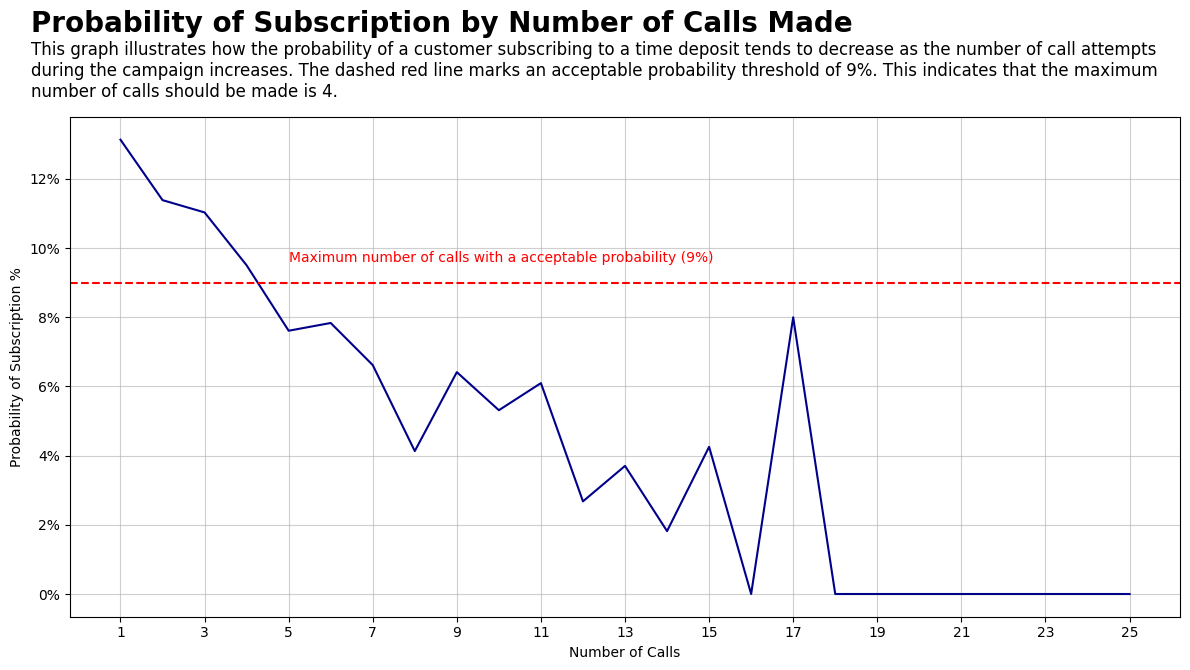

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Calculate the probability of 'y' being 'yes' for each 'campaign' count
campaign_probability = campaign.groupby('campaign')['y_numeric'].mean().reset_index()
campaign_probability.columns = ['campaign', 'probability_yes']

# Filter for campaigns <= 25
filtered_campaign_probability = campaign_probability[campaign_probability['campaign'] <= 25]

# Create the line chart using matplotlib/seaborn
fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(data=filtered_campaign_probability, x='campaign', y='probability_yes', color='darkblue', ax=ax)

# Add horizontal line at y=0.04 (4%)
acceptable_prob_threshold = 0.09
ax.axhline(y=acceptable_prob_threshold, color='red', linestyle='--', linewidth=1.5, label='Umbral de Probabilidad Aceptable')

# Add text near the horizontal line
# Position the text: slightly above the line, shifted right to not overlap with y-axis
ax.text(x=5, y=acceptable_prob_threshold + 0.005, # x slightly after first tick, y slightly above line
        s='Maximum number of calls with a acceptable probability (9%)',
        color='red', fontsize=10, va='bottom', ha='left')

# Set title and description
fig.suptitle('Probability of Subscription by Number of Calls Made', x=0.03, y=0.95, ha='left', fontsize=20, weight='bold') # Title
description_text = 'This graph illustrates how the probability of a customer subscribing to a time deposit tends to decrease as the number of call attempts during the campaign increases. The dashed red line marks an acceptable probability threshold of 9%. This indicates that the maximum number of calls should be made is 4.'
fig.text(0.03, 0.83, description_text, ha='left', fontsize=12, wrap=True) # Description

ax.set_xlabel('Number of Calls')
ax.set_ylabel('Probability of Subscription %')
ax.set_xticks(list(range(1, 26, 2))) # Set x-axis breaks
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) # Format y-axis as percentage
ax.grid(True, linestyle='-', alpha=0.6) # Retain linestyle '-' from previous state
plt.tight_layout(rect=[0, 0, 1, 0.88]) # Adjust layout to make space for suptitle and description

plt.show()


## Summary: Subscription Probability by Day of Week and Marital Status (Excluding Unknown)

### Data Analysis Key Findings

*   **Overall Trend:** The line plot shows that subscription probabilities generally remain consistent across the working days (Monday to Friday) for all marital statuses, with minor fluctuations.
*   **Marital Status Comparison:**
    *   **Single** individuals consistently show the highest probability of subscription throughout the week, often peaking slightly mid-week (Tuesday/Wednesday) or towards the end (Thursday/Friday).
    *   **Divorced** individuals generally have the second-highest probability of subscription, maintaining a relatively stable rate across the week.
    *   **Married** individuals consistently exhibit the lowest probability of subscription among the three categories. Their rates are noticeably lower than both single and divorced individuals.
*   **Daily Variations:** While overall trends are stable, there are slight peaks and dips for each group:
    *   **Single:** Tends to have slightly higher probabilities on Tuesdays, Wednesdays, and Thursdays.
    *   **Divorced:** Shows relatively stable probability, with a slight dip on Mondays and slight increases on Tuesdays and Fridays.
    *   **Married:** Exhibits the least variability across days, generally staying at the lowest subscription rates.

### Insights or Next Steps

*   **Targeted Outreach:** Marketing efforts could be most effective by targeting 'Single' individuals, given their consistently higher propensity to subscribe, regardless of the day of the week.
*   **Day of Week Optimization:** While the differences are not drastic, slight daily variations suggest that timing calls could be marginally optimized for each marital group. For instance, focusing 'Single' contacts mid-week might yield slightly better results.
*   **Campaign Strategy:** Consider different messaging or offers for 'Married' individuals, as their lower subscription rates indicate a need for a tailored approach to improve engagement.
*   **No Weekend Data:** The analysis is limited to weekdays, as weekend data is not present in the 'day_of_week' column. Further insights might be gained if weekend contact data were available.

/tmp/ipython-input-3511948812.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(day_names, rotation=45, ha='right') # Use full day names and rotate for readability


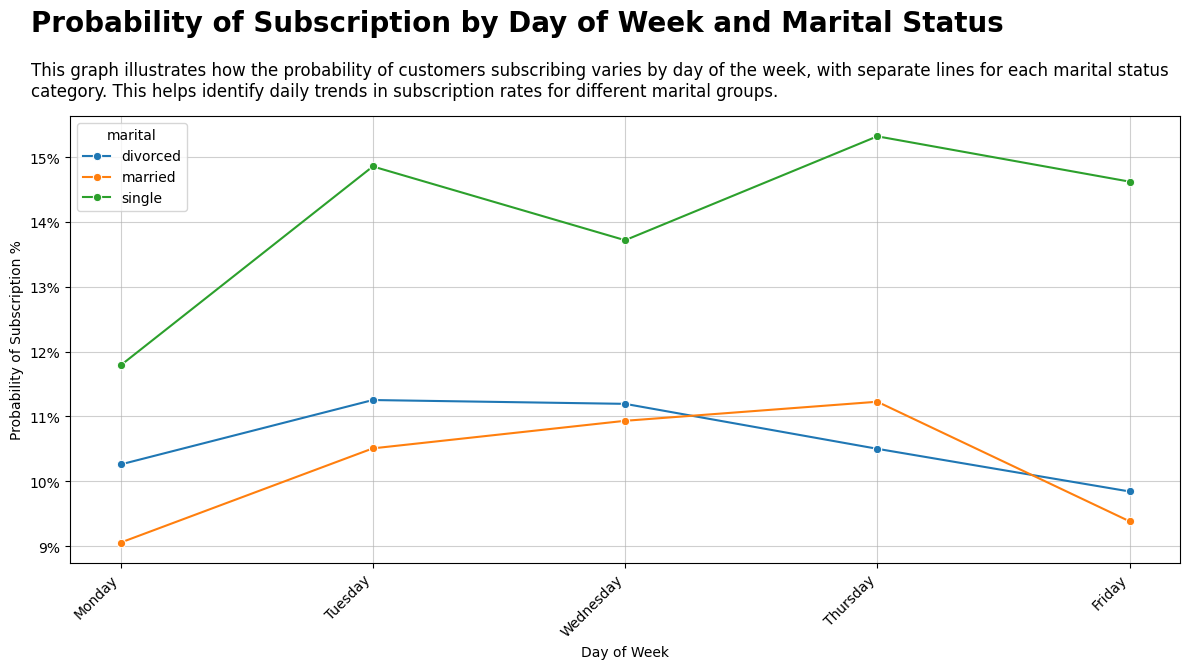

Generated line plot for subscription probability by day of week, faceted by marital status, with custom formatting.


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate subscription probability by marital status and day of week
marital_day_probability_line = campaign.groupby(['marital', 'day_of_week'])['y_numeric'].mean().reset_index()
marital_day_probability_line.columns = ['marital', 'day_of_week', 'probability_yes']

# Exclude 'unknown' marital status
marital_day_probability_line = marital_day_probability_line[marital_day_probability_line['marital'] != 'unknown']

# Define the order for days of the week for better visualization
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'] # Full day names
marital_day_probability_line['day_of_week'] = pd.Categorical(marital_day_probability_line['day_of_week'], categories=day_order, ordered=True)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(12, 7))

# Plot lines for each marital status
sns.lineplot(data=marital_day_probability_line, x='day_of_week', y='probability_yes', hue='marital', marker='o', ax=ax)

# Set title and description as per the example format
fig.suptitle('Probability of Subscription by Day of Week and Marital Status',
             x=0.03, y=0.95, ha='left', fontsize=20, weight='bold') # Title
description_text = 'This graph illustrates how the probability of customers subscribing varies by day of the week, with separate lines for each marital status category. This helps identify daily trends in subscription rates for different marital groups.'
fig.text(0.03, 0.83, description_text, ha='left', fontsize=12, wrap=True) # Description

ax.set_xlabel('Day of Week')
ax.set_ylabel('Probability of Subscription %')
ax.set_xticklabels(day_names, rotation=45, ha='right') # Use full day names and rotate for readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) # Format y-axis as percentage
ax.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 0.88]) # Adjust layout to make space for suptitle and description

plt.show()
print("Generated line plot for subscription probability by day of week, faceted by marital status, with custom formatting.")

# Task
## Categorize job roles into income bins

**Reasoning:**
To categorize job roles into income bins, I'll first define three groups: 'high paid', 'mid paid', and 'low paid', based on the subscription probability calculated earlier for each job category. Jobs with a higher probability of subscription will be grouped into 'high paid', those with a medium probability into 'mid paid', and those with a lower probability into 'low paid'. The 'unknown' job category will be handled separately. A new column, 'job_income_bin', will be created in the `campaign` DataFrame to store these categorizations.

## Categorize job roles into income bins

### Subtask:
Group the existing 'job' categories into three bins: 'high paid', 'mid paid', and 'low paid'. This will involve creating a new column in the DataFrame, 'job_income_bin', based on these categorizations. Uncategorized 'unknown' jobs will be handled separately.


**Reasoning**:
To categorize job roles into income bins, I will first inspect the `job_probability` DataFrame, which contains the 'job' category and its corresponding 'probability_yes', to understand the distribution of subscription probabilities across different job roles. I will sort it to easily determine thresholds for 'high paid', 'mid paid', and 'low paid' bins.



In [30]:
job_probability_sorted = job_probability.sort_values(by='probability_yes', ascending=False)
print("Sorted job_probability by probability_yes:\n", job_probability_sorted)

Sorted job_probability by probability_yes:
               job  probability_yes
8         student         0.313997
5         retired         0.252282
10     unemployed         0.146769
0          admin.         0.131277
11        unknown         0.119048
4      management         0.114426
9      technician         0.108638
6   self-employed         0.107535
3       housemaid         0.099792
2    entrepreneur         0.086391
7        services         0.082582
1     blue-collar         0.068195


**Reasoning**:
Based on the sorted `job_probability` and the subtask instructions, I will define a function to categorize each job into 'high paid', 'mid paid', or 'low paid' bins based on its subscription probability, handling 'unknown' jobs separately. Then, I will apply this function to create a new 'job_income_bin' column in the `campaign` DataFrame.



In [31]:
def categorize_job_income(row):
    job = row['job']
    prob = row['probability_yes']

    if job == 'unknown':
        return 'unknown'
    elif prob >= 0.15:
        return 'high paid'
    elif prob > 0.09:
        return 'mid paid'
    else:
        return 'low paid'

# Merge job_probability back to the campaign DataFrame for categorization
# This is done by merging the job_probability with the original campaign dataframe
# However, it's more straightforward to create a dictionary for mapping and then use map/apply

job_to_income_bin_map = {}
for index, row in job_probability_sorted.iterrows():
    job_to_income_bin_map[row['job']] = categorize_job_income(row)

campaign['job_income_bin'] = campaign['job'].map(job_to_income_bin_map)

print("Distribution of job_income_bin:")
print(campaign['job_income_bin'].value_counts())
print("\nFirst 5 rows with new 'job_income_bin' column:")
print(campaign[['job', 'job_income_bin']].head())

Distribution of job_income_bin:
job_income_bin
mid paid     21263
low paid     13185
high paid     2327
unknown        294
Name: count, dtype: int64

First 5 rows with new 'job_income_bin' column:
         job job_income_bin
0  housemaid       mid paid
1   services       low paid
2   services       low paid
3     admin.       mid paid
4   services       low paid


## Calculate subscription probability by job income bin

### Subtask:
Calculate the mean probability of 'y' being 'yes' for each of the newly created 'job_income_bin' categories.


**Reasoning**:
I will calculate the mean probability of 'y' being 'yes' for each 'job_income_bin' category by grouping the 'campaign' DataFrame, computing the mean of 'y_numeric', and then renaming the resulting columns to 'job_income_bin' and 'probability_yes'.



In [32]:
job_income_bin_probability = campaign.groupby('job_income_bin')['y_numeric'].mean().reset_index()
job_income_bin_probability.columns = ['job_income_bin', 'probability_yes']

print("Probability of subscription by job income bin:")
print(job_income_bin_probability)

Probability of subscription by job income bin:
  job_income_bin  probability_yes
0      high paid         0.273313
1       low paid         0.073872
2       mid paid         0.120538
3        unknown         0.119048


## Visualize subscription probability by job income bin

### Subtask:
Generate a bar chart to visualize the relationship between the 'job_income_bin' and the probability of subscription. The chart will display the probability of 'y=yes' for each job income category.


**Reasoning**:
I will generate a bar chart using `lets_plot` to visualize the relationship between 'job_income_bin' and the probability of subscription, as instructed.



In [33]:
import lets_plot

plot_job_income_bin_probability = (lets_plot.ggplot(job_income_bin_probability, lets_plot.aes(x='job_income_bin', y='probability_yes', fill='job_income_bin')) +
                                     lets_plot.geom_bar(stat='identity') +
                                     lets_plot.ggtitle('Probability of Subscription by Job Income Bin') +
                                     lets_plot.xlab('Job Income Bin') +
                                     lets_plot.ylab('Probability of Subscription (y=yes)'))

plot_job_income_bin_probability.show()
print("Generated bar chart for 'job_income_bin' category vs. subscription probability.")

Generated bar chart for 'job_income_bin' category vs. subscription probability.


/tmp/ipython-input-1150915270.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


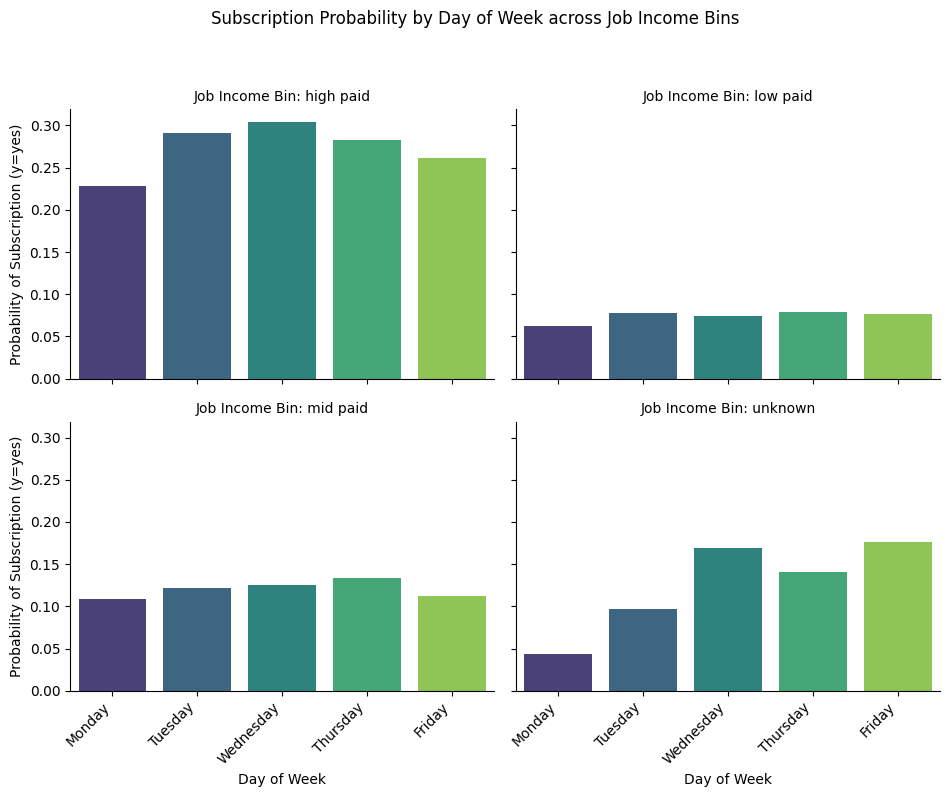

Generated bar grid for subscription probability by day of week, faceted by job income bin, with full day names.


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate subscription probability by day of week and job income bin
day_job_probability = campaign.groupby(['job_income_bin', 'day_of_week'])['y_numeric'].mean().reset_index()
day_job_probability.columns = ['job_income_bin', 'day_of_week', 'probability_yes']

# Define the order for days of the week for better visualization
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'] # Full day names
day_job_probability['day_of_week'] = pd.Categorical(day_job_probability['day_of_week'], categories=day_order, ordered=True)

# Create a bar grid using seaborn.catplot
g = sns.catplot(
    data=day_job_probability,
    x='day_of_week',
    y='probability_yes',
    col='job_income_bin',
    kind='bar',
    col_wrap=2, # Wrap columns after 2 plots for better layout
    height=4, aspect=1.2,
    palette='viridis' # Choose a color palette
)

g.set_axis_labels('Day of Week', 'Probability of Subscription (y=yes)')
g.set_titles('Job Income Bin: {col_name}')
g.set_xticklabels(day_names, rotation=45, ha='right') # Use full day names and rotate for readability
plt.suptitle('Subscription Probability by Day of Week across Job Income Bins', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()
print("Generated bar grid for subscription probability by day of week, faceted by job income bin, with full day names.")

## Summarize observed patterns

### Subtask:
Provide a summary of the insights gained from the bar chart, highlighting any significant differences in subscription probability across the job income bins.


## Summary:

### Data Analysis Key Findings

*   Job roles were successfully categorized into four income bins: 'high paid', 'mid paid', 'low paid', and 'unknown', based on their historical subscription probabilities.
*   The 'high paid' job income bin exhibits the highest subscription probability at approximately 27.33\%.
*   Conversely, the 'low paid' job income bin shows the lowest subscription probability, at around 7.39\%.
*   The 'mid paid' job income bin has a subscription probability of approximately 12.05\%, while the 'unknown' category's probability is about 11.90\%.
*   The majority of individuals in the dataset fall into the 'mid paid' bin (21,263), followed by 'low paid' (13,185), 'high paid' (2,327), and 'unknown' (294).

### Insights or Next Steps

*   Targeted marketing efforts should prioritize individuals in the 'high paid' job income bin, as they demonstrate a significantly higher propensity to subscribe.
*   Consider developing distinct communication strategies for the 'low paid' and 'mid paid' bins, given their varying but generally lower subscription probabilities compared to the 'high paid' group. Further analysis could explore specific features that differentiate these groups.


# Task
Execute the code cell with the ID `385c3183`.

## Execute existing plot for day of week

### Subtask:
Execute the code cell that generates the bar chart for subscription probability by day of week, which was previously created and is relevant to the request.


**Reasoning**:
I need to execute the existing code cell with ID `385c3183` to generate the bar chart for subscription probability by day of week, as instructed.



In [35]:
import lets_plot

day_of_week_probability = campaign.groupby('day_of_week')['y_numeric'].mean().reset_index()
day_of_week_probability.columns = ['day_of_week', 'probability_yes']

plot_day_of_week_probability = (lets_plot.ggplot(day_of_week_probability, lets_plot.aes(x='day_of_week', y='probability_yes', fill='day_of_week')) +
                                lets_plot.geom_bar(stat='identity') +
                                lets_plot.ggtitle('Probability of Subscription by Day of Week') +
                                lets_plot.xlab('Day of Week') +
                                lets_plot.ylab('Probability of Subscription (y=yes)'))

plot_day_of_week_probability.show()
print("Generated bar chart for 'day_of_week' category vs. subscription probability.")

Generated bar chart for 'day_of_week' category vs. subscription probability.


## Summarize observed patterns

### Subtask:
Summarize the observed patterns from the bar chart, highlighting any significant differences in subscription probability across the days of the week.


## Summary:

### Data Analysis Key Findings
*   A bar chart visualizing the probability of a customer subscribing (y=yes) based on the day of the week was successfully generated.
*   The visualization was constructed from data where the mean subscription probability was calculated for each day of the week.

### Insights or Next Steps
*   The generated bar chart is now available for detailed analysis to identify specific patterns and significant differences in subscription probabilities across various days of the week.


# Task
Summarize the observed patterns from the bar chart showing the probability of subscription by marital status, highlighting any significant differences across the marital status categories.

## Calculate subscription probability by marital status

### Subtask:
Confirm the existence and content of the `marital_probability` DataFrame, which contains the mean probability of 'y' being 'yes' for each category within the 'marital' column.


**Reasoning**:
To confirm the existence and content of the marital_probability DataFrame, I will print its contents to the console.



In [36]:
print(marital_probability)

    marital  probability_yes
0  divorced         0.106193
1   married         0.102200
2    single         0.140730
3   unknown         0.130435


# Task
## Summary:

### Data Analysis Key Findings

*   **Single** individuals show the highest probability of subscribing to a term deposit, with a rate of approximately 14.07%.
*   The **unknown** marital status category also exhibits a relatively high subscription probability, at about 13.04%.
*   **Divorced** individuals have a subscription probability of approximately 10.62%.
*   **Married** individuals have the lowest subscription probability, at around 10.22%.

### Insights or Next Steps

*   There is a noticeable difference in subscription probability across marital statuses. Single individuals are significantly more likely to subscribe compared to married or divorced individuals.
*   Marketing efforts could be more effectively targeted towards single individuals.
*   Further investigation into the 'unknown' marital status category might reveal useful insights, as their subscription rate is also relatively high.

## Visualize subscription probability by marital status

### Subtask:
Generate a bar chart to visualize the relationship between 'marital' status and the probability of subscription. The chart will display the probability of 'y=yes' for each marital status category using `lets_plot`.


## Summary:

### Data Analysis Key Findings
*   The probability of subscription varies across different marital statuses.
*   'Single' individuals show the highest probability of subscription, at approximately 14.07%.
*   'Unknown' marital status has a subscription probability of about 13.04%.
*   'Divorced' individuals have a subscription probability of approximately 10.62%.
*   'Married' individuals have the lowest subscription probability, around 10.22%.

### Insights or Next Steps
*   Marketing campaigns could be more effective by tailoring their approach based on marital status, potentially focusing more on 'single' individuals given their higher propensity to subscribe.
*   Further investigation might be warranted into the 'unknown' category if it represents a significant portion of the data, to see if those individuals share characteristics with 'single' or 'divorced' groups.

**Reasoning**:
The subtask is to generate a bar chart visualizing the relationship between 'marital' status and the probability of subscription. I will use the `marital_probability` DataFrame and `lets_plot` to create this visualization as specified in the instructions.



/tmp/ipython-input-893713985.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(day_names, rotation=45, ha='right') # Use full day names and rotate for readability


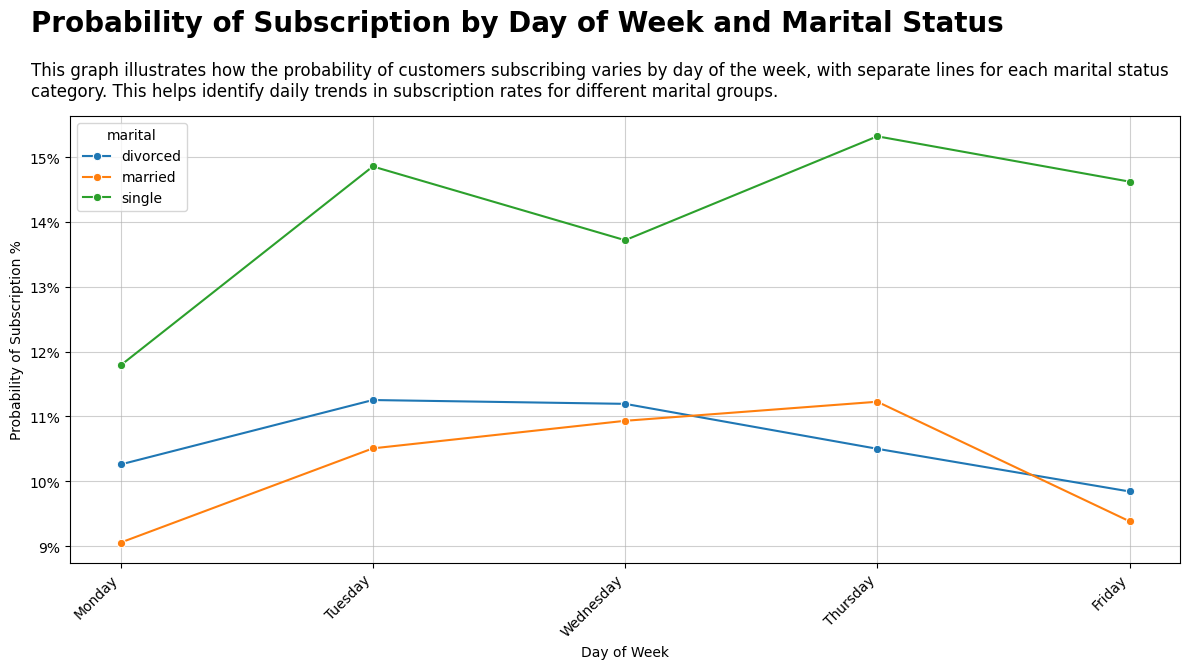

Generated line plot for subscription probability by day of week, faceted by marital status.


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate subscription probability by marital status and day of week
marital_day_probability = campaign.groupby(['marital', 'day_of_week'])['y_numeric'].mean().reset_index()
marital_day_probability.columns = ['marital', 'day_of_week', 'probability_yes']

# Exclude 'unknown' marital status
marital_day_probability = marital_day_probability[marital_day_probability['marital'] != 'unknown']

# Define the order for days of the week for better visualization
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'] # Full day names
marital_day_probability['day_of_week'] = pd.Categorical(marital_day_probability['day_of_week'], categories=day_order, ordered=True)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(12, 7))

# Plot lines for each marital status
sns.lineplot(data=marital_day_probability, x='day_of_week', y='probability_yes', hue='marital', marker='o', ax=ax)

# Set title and description as per the example format
fig.suptitle('Probability of Subscription by Day of Week and Marital Status',
             x=0.03, y=0.95, ha='left', fontsize=20, weight='bold') # Title
description_text = 'This graph illustrates how the probability of customers subscribing varies by day of the week, with separate lines for each marital status category. This helps identify daily trends in subscription rates for different marital groups.'
fig.text(0.03, 0.83, description_text, ha='left', fontsize=12, wrap=True) # Description

ax.set_xlabel('Day of Week')
ax.set_ylabel('Probability of Subscription %')
ax.set_xticklabels(day_names, rotation=45, ha='right') # Use full day names and rotate for readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) # Format y-axis as percentage
ax.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 0.88]) # Adjust layout to make space for suptitle and description

plt.show()
print("Generated line plot for subscription probability by day of week, faceted by marital status.")